# 03 — Machine Learning Analysis

## Human-to-AI Interaction Shift Analysis

This notebook builds machine learning models using the processed Google Trends dataset.

The goal is to test whether AI-related search trend observations and traditional platform observations can be distinguished using machine learning models. This adds a predictive layer to the exploratory data analysis and hypothesis testing results.

The notebook includes:

- machine learning dataset preparation,
- feature engineering,
- AI vs non-AI classification,
- baseline and model comparison,
- time-based model evaluation,
- feature importance analysis,
- error analysis,
- trend score regression,
- final machine learning interpretation.

## 1. Setup and Loading Processed Data

This section imports the required libraries, defines project paths, and loads the processed datasets created in the previous notebooks.

The machine learning models will be trained mainly on the Google Trends dataset because it directly represents the project’s main behavioral evidence.

**Code purpose:** Import the required libraries for data processing, machine learning, and evaluation.

In [433]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

**Code purpose:** Define project folders and check whether the processed data folder exists.

In [434]:
PROJECT_DIR = Path.home() / "Desktop" / "dsa"

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Processed folder exists:", PROCESSED_DIR.exists())
print("Figures folder exists:", FIGURES_DIR.exists())

Project folder: /Users/beren/Desktop/dsa
Processed folder exists: True
Figures folder exists: True


**Code purpose:** Load the processed Google Trends dataset that will be used for machine learning.

In [435]:
google_trends = pd.read_csv(PROCESSED_DIR / "google_trends_cleaned.csv")

google_trends["date"] = pd.to_datetime(google_trends["date"], errors="coerce")

print("Google Trends shape:", google_trends.shape)
google_trends.head()

Google Trends shape: (1091, 5)


,date,category,keyword,platform_type,trend_score
0,2021-04-01,advice_seeking,Yahoo Answers,forum / Q&A platform,56.0
1,2021-05-01,advice_seeking,Yahoo Answers,forum / Q&A platform,22.0
2,2021-06-01,advice_seeking,Yahoo Answers,forum / Q&A platform,14.0
3,2021-07-01,advice_seeking,Yahoo Answers,forum / Q&A platform,12.0
4,2021-08-01,advice_seeking,Yahoo Answers,forum / Q&A platform,11.0


## 2. Machine Learning Goal

The main machine learning goal is to examine whether AI-related search trend observations can be distinguished from traditional platform observations.

The classification task asks:

**Can a machine learning model predict whether a Google Trends observation belongs to an AI-related platform or a non-AI platform?**

The regression task asks:

**Can a machine learning model predict Google Trends search interest from time, category, keyword, and platform information?**

These models are not used to prove individual-level replacement behavior. Instead, they test whether the trend patterns observed in EDA can also be learned by predictive models.

## 3. Preparing the Machine Learning Dataset

This section creates a machine learning dataset from the cleaned Google Trends data. The target variable for classification is whether the observation belongs to an AI platform or not.

**Code purpose:** Create a copy of the Google Trends dataset and remove rows with missing values needed for modeling.

In [436]:
ml_data = google_trends.copy()

ml_data = ml_data.dropna(subset=["date", "category", "keyword", "platform_type", "trend_score"])

print("ML dataset shape:", ml_data.shape)
ml_data.head()

ML dataset shape: (1091, 5)


,date,category,keyword,platform_type,trend_score
0,2021-04-01,advice_seeking,Yahoo Answers,forum / Q&A platform,56.0
1,2021-05-01,advice_seeking,Yahoo Answers,forum / Q&A platform,22.0
2,2021-06-01,advice_seeking,Yahoo Answers,forum / Q&A platform,14.0
3,2021-07-01,advice_seeking,Yahoo Answers,forum / Q&A platform,12.0
4,2021-08-01,advice_seeking,Yahoo Answers,forum / Q&A platform,11.0


**Code purpose:** Create the binary classification target variable `is_ai_platform`.

In [437]:
ml_data["is_ai_platform"] = (ml_data["platform_type"] == "AI platform").astype(int)

ml_data[["date", "category", "keyword", "platform_type", "trend_score", "is_ai_platform"]].head()

,date,category,keyword,platform_type,trend_score,is_ai_platform
0,2021-04-01,advice_seeking,Yahoo Answers,forum / Q&A platform,56.0,0
1,2021-05-01,advice_seeking,Yahoo Answers,forum / Q&A platform,22.0,0
2,2021-06-01,advice_seeking,Yahoo Answers,forum / Q&A platform,14.0,0
3,2021-07-01,advice_seeking,Yahoo Answers,forum / Q&A platform,12.0,0
4,2021-08-01,advice_seeking,Yahoo Answers,forum / Q&A platform,11.0,0


**Code purpose:** Check the class balance between AI and non-AI observations.

In [438]:
class_balance = (
    ml_data["is_ai_platform"]
    .value_counts()
    .rename(index={0: "non_ai_platform", 1: "ai_platform"})
    .reset_index()
)

class_balance.columns = ["class", "count"]

class_balance["percentage"] = (
    class_balance["count"] / class_balance["count"].sum() * 100
).round(2)

class_balance

,class,count,percentage
0,non_ai_platform,707,64.8
1,ai_platform,384,35.2


### Class Balance Interpretation

The class balance table shows how many observations belong to AI-related platforms and how many belong to non-AI platforms. This is important because imbalanced data can make accuracy misleading.

For this reason, the classification models will be evaluated using multiple metrics, including accuracy, precision, recall, and F1-score.

## 4. Feature Engineering

This section creates time-based features from the date column. These features allow the models to use temporal information such as year and month.

The created features include:

- `year`
- `month`
- `quarter`
- `time_index`

The `time_index` variable represents the chronological order of the observations and helps the model capture general time progression.

**Code purpose:** Create time-based features from the date column.

In [439]:
ml_data["year"] = ml_data["date"].dt.year
ml_data["month"] = ml_data["date"].dt.month
ml_data["quarter"] = ml_data["date"].dt.quarter

ml_data = ml_data.sort_values("date").reset_index(drop=True)

ml_data["time_index"] = (
    ml_data["date"] - ml_data["date"].min()
).dt.days

ml_data.head()

,date,category,keyword,platform_type,trend_score,is_ai_platform,year,month,quarter,time_index
0,2021-04-01,advice_seeking,Yahoo Answers,forum / Q&A platform,56.0,0,2021,4,2,0
1,2021-04-01,general_help_seeking,quora,forum / Q&A platform,70.0,0,2021,4,2,0
2,2021-04-01,advice_seeking,ai friend,AI platform,2.0,1,2021,4,2,0
3,2021-04-01,advice_seeking,Ask.fm,forum / Q&A platform,13.0,0,2021,4,2,0
4,2021-04-01,general_help_seeking,chatgpt help,AI platform,0.0,1,2021,4,2,0


**Code purpose:** Check the final machine learning dataset columns and basic structure.

In [440]:
print("ML dataset columns:")
print(ml_data.columns.tolist())

print("\nFinal ML dataset shape:", ml_data.shape)

ml_data[[
    "date",
    "year",
    "month",
    "quarter",
    "time_index",
    "category",
    "keyword",
    "platform_type",
    "trend_score",
    "is_ai_platform"
]].head()

ML dataset columns:
['date', 'category', 'keyword', 'platform_type', 'trend_score', 'is_ai_platform', 'year', 'month', 'quarter', 'time_index']

Final ML dataset shape: (1091, 10)


,date,year,month,quarter,time_index,category,keyword,platform_type,trend_score,is_ai_platform
0,2021-04-01,2021,4,2,0,advice_seeking,Yahoo Answers,forum / Q&A platform,56.0,0
1,2021-04-01,2021,4,2,0,general_help_seeking,quora,forum / Q&A platform,70.0,0
2,2021-04-01,2021,4,2,0,advice_seeking,ai friend,AI platform,2.0,1
3,2021-04-01,2021,4,2,0,advice_seeking,Ask.fm,forum / Q&A platform,13.0,0
4,2021-04-01,2021,4,2,0,general_help_seeking,chatgpt help,AI platform,0.0,1


## 5. Feature Sets for Classification

Two feature sets are prepared for classification.

The first feature set is a **pattern-only feature set**. It does not include keyword names or platform type. This makes the task more difficult, but it tests whether AI-related observations can be identified from time, category, and trend score patterns.

The second feature set is a **full feature set**. It includes keyword names. This is useful as a practical classification model, but it is easier because the keyword itself contains strong information.

**Code purpose:** Define pattern-only and full feature sets for AI vs non-AI classification.

In [441]:
pattern_features = [
    "trend_score",
    "year",
    "month",
    "quarter",
    "time_index",
    "category"
]

full_features = [
    "trend_score",
    "year",
    "month",
    "quarter",
    "time_index",
    "category",
    "keyword"
]

target = "is_ai_platform"

X_pattern = ml_data[pattern_features]
X_full = ml_data[full_features]
y = ml_data[target]

print("Pattern-only features:", pattern_features)
print("Full features:", full_features)
print("Target:", target)

Pattern-only features: ['trend_score', 'year', 'month', 'quarter', 'time_index', 'category']
Full features: ['trend_score', 'year', 'month', 'quarter', 'time_index', 'category', 'keyword']
Target: is_ai_platform


**Code purpose:** Identify numeric and categorical columns for preprocessing.

In [442]:
pattern_numeric_features = [
    "trend_score",
    "year",
    "month",
    "quarter",
    "time_index"
]

pattern_categorical_features = [
    "category"
]

full_numeric_features = [
    "trend_score",
    "year",
    "month",
    "quarter",
    "time_index"
]

full_categorical_features = [
    "category",
    "keyword"
]

print("Pattern numeric features:", pattern_numeric_features)
print("Pattern categorical features:", pattern_categorical_features)

print("\nFull numeric features:", full_numeric_features)
print("Full categorical features:", full_categorical_features)

Pattern numeric features: ['trend_score', 'year', 'month', 'quarter', 'time_index']
Pattern categorical features: ['category']

Full numeric features: ['trend_score', 'year', 'month', 'quarter', 'time_index']
Full categorical features: ['category', 'keyword']


## 6. Random Train-Test Split for Classification

This section creates random train-test splits for both feature sets. The random split is useful for initial model comparison.

Later, a time-based split will also be used because the data has a chronological structure.

**Code purpose:** Split the pattern-only and full feature datasets into training and testing sets.

In [443]:
X_pattern_train, X_pattern_test, y_train, y_test = train_test_split(
    X_pattern,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(
    X_full,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Pattern train shape:", X_pattern_train.shape)
print("Pattern test shape:", X_pattern_test.shape)

print("Full train shape:", X_full_train.shape)
print("Full test shape:", X_full_test.shape)

Pattern train shape: (872, 6)
Pattern test shape: (219, 6)
Full train shape: (872, 7)
Full test shape: (219, 7)


**Code purpose:** Check the class distribution in the training and testing targets.

In [444]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training target distribution:
is_ai_platform
0    0.648
1    0.352
Name: proportion, dtype: float64

Testing target distribution:
is_ai_platform
0    0.648
1    0.352
Name: proportion, dtype: float64


## 7. Classification Helper Function

This section defines a helper function to evaluate classification models in a consistent way. The same metrics will be used for all models so that their results can be compared fairly.

The metrics include accuracy, precision, recall, F1-score, and ROC-AUC.

**Code purpose:** Define a reusable function for evaluating classification models.

In [445]:
def evaluate_classifier(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan
    
    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc
    }
    
    return results

## 8. Baseline Classification Model

Before training machine learning models, I first create a baseline model. The baseline predicts the most frequent class in the training data.

This gives a minimum performance level. If the real models cannot perform better than this baseline, then they are not useful.

**Code purpose:** Train and evaluate a baseline classifier using the most frequent class.

In [446]:
baseline_classifier = DummyClassifier(strategy="most_frequent", random_state=42)

baseline_classifier.fit(X_pattern_train, y_train)

baseline_results = evaluate_classifier(
    baseline_classifier,
    X_pattern_test,
    y_test,
    "Baseline - most frequent class"
)

baseline_results

{'model': 'Baseline - most frequent class',
 'accuracy': 0.6484018264840182,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0,
 'roc_auc': np.float64(0.5)}

### Baseline Model Interpretation

The baseline model predicts only the majority class, which is the non-AI platform class in this dataset. Because of this, it gets a moderate accuracy score, but its precision, recall, and F1-score for the AI class are 0.

This means that the baseline model is not useful for the main goal of the project, because it cannot identify AI-related observations. Therefore, the later machine learning models need to perform better than this baseline, especially in terms of recall and F1-score.

## 9. Logistic Regression Classification

Logistic Regression is used as a simple and interpretable classification model. It is useful because it shows whether a relatively simple linear model can separate AI and non-AI observations.

I first train Logistic Regression using the pattern-only feature set.

**Code purpose:** Create preprocessing pipelines for pattern-only and full feature sets.

In [447]:
pattern_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), pattern_numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), pattern_categorical_features)
    ]
)

full_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), full_numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), full_categorical_features)
    ]
)

print("Pattern preprocessor created.")
print("Full preprocessor created.")

Pattern preprocessor created.
Full preprocessor created.


**Code purpose:** Train and evaluate Logistic Regression using the pattern-only feature set.

In [448]:
logistic_pattern_model = Pipeline(
    steps=[
        ("preprocessor", pattern_preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_pattern_model.fit(X_pattern_train, y_train)

logistic_pattern_results = evaluate_classifier(
    logistic_pattern_model,
    X_pattern_test,
    y_test,
    "Logistic Regression - pattern features"
)

logistic_pattern_results

{'model': 'Logistic Regression - pattern features',
 'accuracy': 0.8401826484018264,
 'precision': 1.0,
 'recall': 0.5454545454545454,
 'f1_score': 0.7058823529411765,
 'roc_auc': np.float64(0.8435613682092555)}

The full feature set includes keyword names. This can improve performance, but it also makes the classification task easier because some keywords directly indicate whether the observation is AI-related.

**Code purpose:** Train and evaluate Logistic Regression using the full feature set.

In [449]:
logistic_full_model = Pipeline(
    steps=[
        ("preprocessor", full_preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_full_model.fit(X_full_train, y_full_train)

logistic_full_results = evaluate_classifier(
    logistic_full_model,
    X_full_test,
    y_full_test,
    "Logistic Regression - full features"
)

logistic_full_results

{'model': 'Logistic Regression - full features',
 'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1_score': 1.0,
 'roc_auc': np.float64(1.0)}

### Logistic Regression Interpretation

The pattern-only Logistic Regression model performs better than the baseline, which means that even a simple model can use trend score, time, and category information to identify some AI-related observations.

However, its recall is lower than the tree-based models, meaning it misses more AI observations. The full-feature Logistic Regression model performs perfectly because it includes keyword names, which give very strong information about whether an observation is AI-related. For this reason, the pattern-only result is more meaningful for understanding trend-pattern differences.

## 10. Decision Tree Classification

A Decision Tree model is trained because it can capture non-linear patterns and is easier to interpret than more complex ensemble models.

The same two feature sets are tested again: pattern-only features and full features.

**Code purpose:** Train and evaluate a Decision Tree classifier using the pattern-only feature set.

In [450]:
tree_pattern_model = Pipeline(
    steps=[
        ("preprocessor", pattern_preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ))
    ]
)

tree_pattern_model.fit(X_pattern_train, y_train)

tree_pattern_results = evaluate_classifier(
    tree_pattern_model,
    X_pattern_test,
    y_test,
    "Decision Tree - pattern features"
)

tree_pattern_results

{'model': 'Decision Tree - pattern features',
 'accuracy': 0.8858447488584474,
 'precision': 0.8095238095238095,
 'recall': 0.8831168831168831,
 'f1_score': 0.84472049689441,
 'roc_auc': np.float64(0.9552313883299799)}

**Code purpose:** Train and evaluate a Decision Tree classifier using the full feature set.

In [451]:
tree_full_model = Pipeline(
    steps=[
        ("preprocessor", full_preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ))
    ]
)

tree_full_model.fit(X_full_train, y_full_train)

tree_full_results = evaluate_classifier(
    tree_full_model,
    X_full_test,
    y_full_test,
    "Decision Tree - full features"
)

tree_full_results

{'model': 'Decision Tree - full features',
 'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1_score': 1.0,
 'roc_auc': np.float64(1.0)}

### Decision Tree Interpretation

The pattern-only Decision Tree performs better than Logistic Regression. This suggests that the relationship between time, trend score, category, and AI-related observations may not be fully linear.

The full-feature Decision Tree reaches perfect performance because keyword names make the classification task much easier. Therefore, the pattern-only Decision Tree is more useful for evaluating whether the model can learn from trend behavior rather than from keyword identity.

## 11. Random Forest Classification

Random Forest is used as a stronger classification model. It combines many decision trees and can capture more complex relationships in the data.

This model is useful for checking whether a more flexible method performs better than Logistic Regression and a single Decision Tree.

**Code purpose:** Train and evaluate a Random Forest classifier using the pattern-only feature set.

In [452]:
forest_pattern_model = Pipeline(
    steps=[
        ("preprocessor", pattern_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            random_state=42
        ))
    ]
)

forest_pattern_model.fit(X_pattern_train, y_train)

forest_pattern_results = evaluate_classifier(
    forest_pattern_model,
    X_pattern_test,
    y_test,
    "Random Forest - pattern features"
)

forest_pattern_results

{'model': 'Random Forest - pattern features',
 'accuracy': 0.9315068493150684,
 'precision': 0.918918918918919,
 'recall': 0.8831168831168831,
 'f1_score': 0.9006622516556292,
 'roc_auc': np.float64(0.9919974391805377)}

**Code purpose:** Train and evaluate a Random Forest classifier using the full feature set.

In [453]:
forest_full_model = Pipeline(
    steps=[
        ("preprocessor", full_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            random_state=42
        ))
    ]
)

forest_full_model.fit(X_full_train, y_full_train)

forest_full_results = evaluate_classifier(
    forest_full_model,
    X_full_test,
    y_full_test,
    "Random Forest - full features"
)

forest_full_results

{'model': 'Random Forest - full features',
 'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1_score': 1.0,
 'roc_auc': np.float64(1.0)}

### Random Forest Interpretation

The pattern-only Random Forest gives the strongest performance among the pattern-only models. This suggests that combining multiple decision trees helps capture more complex differences between AI-related and non-AI search observations.

The full-feature Random Forest also reaches perfect performance because keyword information strongly identifies the class. Therefore, the Random Forest pattern-only model is the most useful model for supporting the project’s main ML argument.

## 12. Classification Model Comparison

This section compares all classification models using the same evaluation metrics.

The pattern-only models test whether AI and non-AI observations can be separated without using keyword names. The full models test classification performance when keyword information is included.

**Code purpose:** Combine classification results into one comparison table.

In [454]:
classification_results = pd.DataFrame([
    baseline_results,
    logistic_pattern_results,
    logistic_full_results,
    tree_pattern_results,
    tree_full_results,
    forest_pattern_results,
    forest_full_results
])

classification_results = classification_results.sort_values(
    "f1_score",
    ascending=False
).reset_index(drop=True)

classification_results

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression - full features,1.000000,1.000000,1.000000,1.000000,1.000000
1,Decision Tree - full features,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest - full features,1.000000,1.000000,1.000000,1.000000,1.000000
3,Random Forest - pattern features,0.931507,0.918919,0.883117,0.900662,0.991997
4,Decision Tree - pattern features,0.885845,0.809524,0.883117,0.844720,0.955231
5,Logistic Regression - pattern features,0.840183,1.000000,0.545455,0.705882,0.843561
6,Baseline - most frequent class,0.648402,0.000000,0.000000,0.000000,0.500000


**Code purpose:** Plot F1-score comparison across classification models.

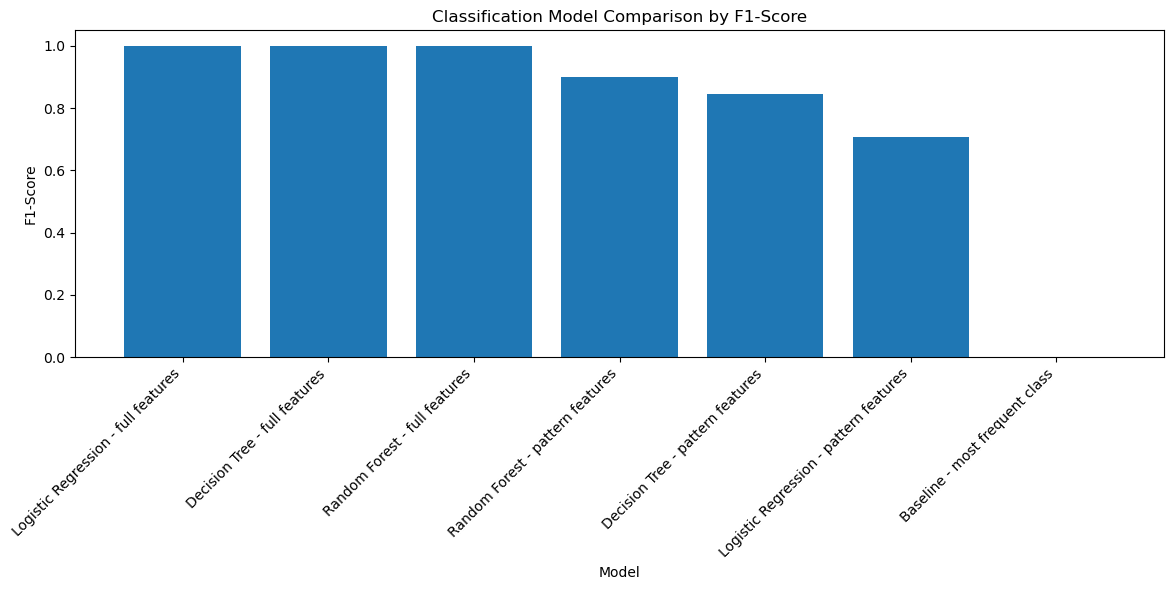

In [455]:
plt.figure(figsize=(12, 6))

plt.bar(
    classification_results["model"],
    classification_results["f1_score"]
)

plt.title("Classification Model Comparison by F1-Score")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Classification Model Comparison Interpretation

The baseline model gives the minimum reference point because it predicts only the majority class. Since its F1-score for the AI class is 0, it is not useful for identifying AI-related observations.

The pattern-only models are more important for this project because they do not use keyword names. These models only use trend score, time-based features, and category information. Their performance is clearly better than the baseline, which suggests that AI-related and non-AI observations have distinguishable trend patterns.

Among the pattern-only models, the Random Forest model performs the best. This suggests that a more flexible model can capture non-linear differences between AI-related and traditional platform observations better than Logistic Regression.

The full-feature models reach perfect performance because they include keyword names. This result should be interpreted carefully. It does not mean the model discovered a deep behavioral pattern by itself; rather, the keyword variable gives very strong information about whether an observation is AI-related. Therefore, the full-feature models are useful as a practical classification check, but the pattern-only models are more meaningful for supporting the project’s main argument.

## 13. Confusion Matrix and Detailed Classification Report

This section looks more closely at the best pattern-only classification model. The pattern-only model is important because it does not use keyword names, so it gives a more realistic test of whether trend patterns can distinguish AI-related observations from non-AI observations.

The Random Forest pattern-only model is selected because it had the strongest performance among the pattern-only models.

**Code purpose:** Generate predictions from the best pattern-only classification model.

In [456]:
best_pattern_classifier = forest_pattern_model

pattern_y_pred = best_pattern_classifier.predict(X_pattern_test)
pattern_y_proba = best_pattern_classifier.predict_proba(X_pattern_test)[:, 1]

print("Classification report for Random Forest pattern-only model:")
print(classification_report(y_test, pattern_y_pred, target_names=["non-AI", "AI"]))

Classification report for Random Forest pattern-only model:
              precision    recall  f1-score   support

      non-AI       0.94      0.96      0.95       142
          AI       0.92      0.88      0.90        77

    accuracy                           0.93       219
   macro avg       0.93      0.92      0.92       219
weighted avg       0.93      0.93      0.93       219



**Code purpose:** Create and display the confusion matrix for the best pattern-only classification model.

In [457]:
cm = confusion_matrix(y_test, pattern_y_pred)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=["Actual non-AI", "Actual AI"],
    columns=["Predicted non-AI", "Predicted AI"]
)

confusion_matrix_df

,Predicted non-AI,Predicted AI
Actual non-AI,136,6
Actual AI,9,68


**Code purpose:** Plot the confusion matrix for the best pattern-only classification model.

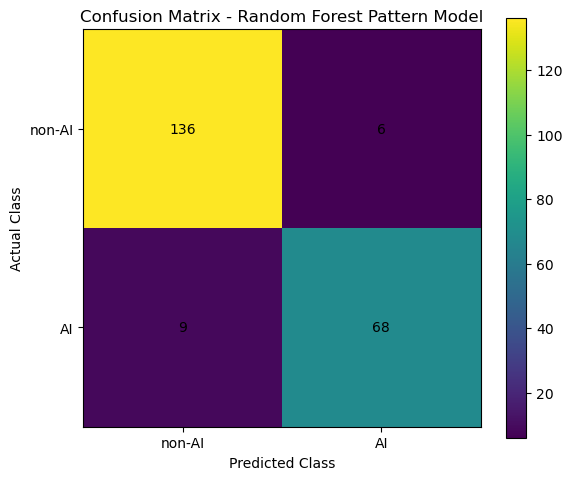

In [458]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Random Forest Pattern Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks([0, 1], ["non-AI", "AI"])
plt.yticks([0, 1], ["non-AI", "AI"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows how many AI and non-AI observations were classified correctly or incorrectly.

This is useful because accuracy alone does not show which class the model struggles with. Since the project focuses on AI-related observations, recall and F1-score are especially important for understanding whether the model can identify AI-related trend observations.

## 14. Cross-Validation for Classification

This section uses cross-validation to evaluate the Random Forest pattern-only model more reliably. Cross-validation checks whether the model performs consistently across different train-test splits.

The full feature models are not used for this step because keyword names make the classification task too easy. The pattern-only model is more useful for testing whether trend patterns themselves are informative.

**Code purpose:** Run 5-fold cross-validation on the Random Forest pattern-only classification model.

In [459]:
cv_f1_scores = cross_val_score(
    forest_pattern_model,
    X_pattern,
    y,
    cv=5,
    scoring="f1"
)

cv_accuracy_scores = cross_val_score(
    forest_pattern_model,
    X_pattern,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation F1 scores:", cv_f1_scores)
print("Mean F1:", cv_f1_scores.mean().round(4))
print("Standard deviation F1:", cv_f1_scores.std().round(4))

print("\nCross-validation accuracy scores:", cv_accuracy_scores)
print("Mean accuracy:", cv_accuracy_scores.mean().round(4))
print("Standard deviation accuracy:", cv_accuracy_scores.std().round(4))

Cross-validation F1 scores: [1.         0.95890411 0.95238095 0.72868217 0.28571429]
Mean F1: 0.7851
Standard deviation F1: 0.2672

Cross-validation accuracy scores: [1.         0.97247706 0.96788991 0.83944954 0.5412844 ]
Mean accuracy: 0.8642
Standard deviation accuracy: 0.1708


**Code purpose:** Summarize cross-validation results in a table.

In [460]:
cross_validation_summary = pd.DataFrame({
    "metric": ["F1-score", "Accuracy"],
    "mean_score": [
        cv_f1_scores.mean(),
        cv_accuracy_scores.mean()
    ],
    "standard_deviation": [
        cv_f1_scores.std(),
        cv_accuracy_scores.std()
    ]
})

cross_validation_summary

,metric,mean_score,standard_deviation
0,F1-score,0.785136,0.267186
1,Accuracy,0.864220,0.170765


### Cross-Validation Interpretation

The cross-validation results show that the Random Forest pattern-only model performs better than the baseline on average. The mean F1-score and accuracy are clearly higher than the baseline model, which supports the idea that trend score, category, and time-based features contain useful information for distinguishing AI-related observations.

However, the standard deviation is relatively high. This suggests that model performance changes across different folds. This is expected because Google Trends data has a strong time-based structure, and AI-related search behavior changes significantly across years. Therefore, cross-validation supports the usefulness of the model, but it also shows that performance depends on which time periods are included in training and testing.

## 15. Time-Based Classification Evaluation

The previous models used a random train-test split. However, the Google Trends data has a time-based structure. For this reason, I also test the model with a time-based split.

In this evaluation, earlier observations are used for training and later observations are used for testing. This is a stricter evaluation because it asks whether earlier trend patterns can help classify later observations.

**Code purpose:** Create a time-based train-test split using the pattern-only feature set.

In [461]:
ml_data_time_sorted = ml_data.sort_values("date").reset_index(drop=True)

split_index = int(len(ml_data_time_sorted) * 0.8)

train_time_data = ml_data_time_sorted.iloc[:split_index].copy()
test_time_data = ml_data_time_sorted.iloc[split_index:].copy()

X_time_train = train_time_data[pattern_features]
y_time_train = train_time_data[target]

X_time_test = test_time_data[pattern_features]
y_time_test = test_time_data[target]

print("Time-based train shape:", X_time_train.shape)
print("Time-based test shape:", X_time_test.shape)

print("\nTrain date range:")
print(train_time_data["date"].min(), "to", train_time_data["date"].max())

print("\nTest date range:")
print(test_time_data["date"].min(), "to", test_time_data["date"].max())

print("\nTime-based train class balance:")
print(y_time_train.value_counts(normalize=True).round(3))

print("\nTime-based test class balance:")
print(y_time_test.value_counts(normalize=True).round(3))

Time-based train shape: (872, 6)
Time-based test shape: (219, 6)

Train date range:
2021-04-01 00:00:00 to 2025-04-06 00:00:00

Test date range:
2025-04-13 00:00:00 to 2026-04-12 00:00:00

Time-based train class balance:
is_ai_platform
0    0.648
1    0.352
Name: proportion, dtype: float64

Time-based test class balance:
is_ai_platform
0    0.648
1    0.352
Name: proportion, dtype: float64


**Code purpose:** Train and evaluate a Random Forest classifier using the time-based split.

In [462]:
time_forest_model = Pipeline(
    steps=[
        ("preprocessor", pattern_preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            random_state=42
        ))
    ]
)

time_forest_model.fit(X_time_train, y_time_train)

time_forest_results = evaluate_classifier(
    time_forest_model,
    X_time_test,
    y_time_test,
    "Random Forest - time-based pattern split"
)

time_forest_results

{'model': 'Random Forest - time-based pattern split',
 'accuracy': 0.5844748858447488,
 'precision': 0.39705882352941174,
 'recall': 0.35064935064935066,
 'f1_score': 0.3724137931034483,
 'roc_auc': np.float64(0.4153100420706054)}

**Code purpose:** Compare random split and time-based split results for the pattern-only Random Forest model.

In [463]:
time_comparison = pd.DataFrame([
    forest_pattern_results,
    time_forest_results
])

time_comparison

,model,accuracy,precision,recall,f1_score,roc_auc
0,Random Forest - pattern features,0.931507,0.918919,0.883117,0.900662,0.991997
1,Random Forest - time-based pattern split,0.584475,0.397059,0.350649,0.372414,0.415310


**Code purpose:** Display the classification report for the time-based split model.

In [464]:
time_y_pred = time_forest_model.predict(X_time_test)

print("Classification report for time-based Random Forest model:")
print(classification_report(y_time_test, time_y_pred, target_names=["non-AI", "AI"]))

Classification report for time-based Random Forest model:
              precision    recall  f1-score   support

      non-AI       0.67      0.71      0.69       142
          AI       0.40      0.35      0.37        77

    accuracy                           0.58       219
   macro avg       0.53      0.53      0.53       219
weighted avg       0.57      0.58      0.58       219



### Time-Based Split Interpretation

The time-based split gives weaker results than the random split. This is expected because the model is trained on earlier observations and tested on later observations, where AI-related search behavior may have changed substantially.

The lower F1-score shows that future-period classification is more difficult than random classification. This means that the model can learn strong patterns when observations from different time periods are mixed, but it has more difficulty generalizing from older search behavior to newer search behavior.

This result is still useful for the project because it shows that AI-related search behavior is dynamic and changes over time. Therefore, the random split results support pattern distinguishability, while the time-based split shows that the shift toward AI-related search behavior is not static and may evolve across periods.

## 16. Feature Importance for Classification

This section examines which features are most important for the Random Forest pattern-only classification model.

The pattern-only model is used because it does not include keyword names. Therefore, feature importance helps show whether time, category, and trend score features contribute to distinguishing AI-related observations from non-AI observations.

**Code purpose:** Extract feature names from the pattern-only preprocessing pipeline.

In [465]:
pattern_feature_names = []

# Numeric feature names
pattern_feature_names.extend(pattern_numeric_features)

# Categorical feature names after one-hot encoding
category_feature_names = (
    forest_pattern_model
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(pattern_categorical_features)
    .tolist()
)

pattern_feature_names.extend(category_feature_names)

print("Number of transformed features:", len(pattern_feature_names))
print(pattern_feature_names)

Number of transformed features: 8
['trend_score', 'year', 'month', 'quarter', 'time_index', 'category_advice_seeking', 'category_general_help_seeking', 'category_study_support']


**Code purpose:** Extract and display feature importance values from the Random Forest pattern-only model.

In [466]:
feature_importance = (
    forest_pattern_model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance_df = pd.DataFrame({
    "feature": pattern_feature_names,
    "importance": feature_importance
}).sort_values("importance", ascending=False)

feature_importance_df

,feature,importance
0,trend_score,0.659023
4,time_index,0.143894
1,year,0.081812
5,category_advice_seeking,0.041114
2,month,0.026233
7,category_study_support,0.021857
6,category_general_help_seeking,0.016665
3,quarter,0.009401


**Code purpose:** Plot the feature importance values for the Random Forest pattern-only model.

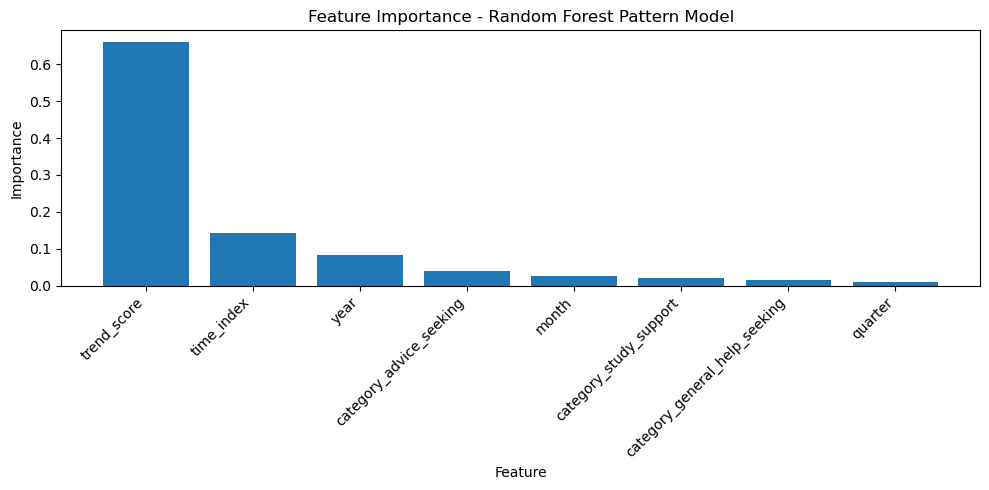

In [467]:
plt.figure(figsize=(10, 5))

plt.bar(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)

plt.title("Feature Importance - Random Forest Pattern Model")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

The feature importance results show which variables the Random Forest pattern-only model used most when distinguishing AI-related observations from non-AI observations.

If time-related features such as `time_index` or `year` are important, this suggests that the timing of search behavior matters. If `trend_score` is important, this suggests that the level of search interest helps separate AI-related observations from non-AI observations. If category features are important, this suggests that the type of help-seeking context also affects the classification.

This supports the project because the model is not using keyword names in this version. Instead, it relies on general trend behavior and category-level information.

## 17. Classification Error Analysis

This section examines the observations that the Random Forest pattern-only model classified incorrectly.

Error analysis is useful because it shows where the model struggles. This helps avoid only reporting performance scores and gives a clearer understanding of the model behavior.

**Code purpose:** Create a test set table with actual labels, predicted labels, and prediction probabilities.

In [468]:
classification_error_data = X_pattern_test.copy()

classification_error_data["actual_is_ai"] = y_test.values
classification_error_data["predicted_is_ai"] = pattern_y_pred
classification_error_data["predicted_ai_probability"] = pattern_y_proba

classification_error_data["prediction_result"] = np.where(
    classification_error_data["actual_is_ai"] == classification_error_data["predicted_is_ai"],
    "correct",
    "incorrect"
)

classification_error_data.head()

,trend_score,year,month,quarter,time_index,category,actual_is_ai,predicted_is_ai,predicted_ai_probability,prediction_result
755,9.0,2024,9,3,1277,study_support,0,0,0.101705,correct
247,16.0,2022,5,2,423,study_support,0,0,0.044692,correct
389,51.0,2023,1,1,661,study_support,0,0,0.040476,correct
202,0.0,2022,3,1,339,study_support,1,1,0.956662,correct
733,34.0,2024,8,3,1242,study_support,0,0,0.103549,correct


**Code purpose:** Count correct and incorrect predictions.

In [469]:
classification_error_summary = (
    classification_error_data["prediction_result"]
    .value_counts()
    .reset_index()
)

classification_error_summary.columns = ["prediction_result", "count"]

classification_error_summary["percentage"] = (
    classification_error_summary["count"] /
    classification_error_summary["count"].sum() * 100
).round(2)

classification_error_summary

,prediction_result,count,percentage
0,correct,204,93.15
1,incorrect,15,6.85


**Code purpose:** Display incorrectly classified observations.

In [470]:
misclassified_observations = classification_error_data[
    classification_error_data["prediction_result"] == "incorrect"
].copy()

misclassified_observations = misclassified_observations.sort_values(
    "predicted_ai_probability",
    ascending=False
)

misclassified_observations

,trend_score,year,month,quarter,time_index,category,actual_is_ai,predicted_is_ai,predicted_ai_probability,prediction_result
871,6.0,2025,4,2,1466,study_support,0,1,0.594249,incorrect
857,6.0,2025,3,1,1445,study_support,0,1,0.542877,incorrect
854,6.0,2025,3,1,1438,study_support,0,1,0.542877,incorrect
1081,33.0,2026,4,2,1826,general_help_seeking,0,1,0.525980,incorrect
859,6.0,2025,3,1,1452,study_support,0,1,0.525113,incorrect
873,5.0,2025,4,2,1473,study_support,0,1,0.514262,incorrect
832,6.0,2025,2,1,1403,study_support,1,0,0.494437,incorrect
1012,12.0,2025,12,4,1705,general_help_seeking,1,0,0.475359,incorrect
809,3.0,2024,12,4,1368,study_support,1,0,0.473521,incorrect
888,6.0,2025,5,2,1494,study_support,1,0,0.464782,incorrect


**Code purpose:** Count misclassified observations by category.

In [471]:
misclassification_by_category = (
    misclassified_observations
    .groupby("category")
    .size()
    .reset_index(name="misclassified_count")
    .sort_values("misclassified_count", ascending=False)
)

misclassification_by_category

,category,misclassified_count
1,study_support,13
0,general_help_seeking,2


**Code purpose:** Compare average predicted AI probability for correct and incorrect predictions.

In [472]:
probability_error_summary = (
    classification_error_data
    .groupby("prediction_result")["predicted_ai_probability"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

probability_error_summary

,prediction_result,mean,min,max
0,correct,0.354385,0.028146,0.956662
1,incorrect,0.476263,0.352493,0.594249


### Classification Error Analysis Interpretation

The error analysis shows that the Random Forest pattern-only model correctly classified 204 out of 219 test observations. Only 15 observations were misclassified, which means most AI and non-AI observations were separated successfully without using keyword names.

Most of the misclassified observations are in the study-support category. This suggests that study-related AI and traditional platform trends are harder to separate than the other categories. Since the model does not use keyword names, it only sees the category, time, and trend score. In some periods, `chatgpt study`, `chegg`, and `course hero` can have similar trend scores, so the model may confuse them.

This does not mean the model failed. Instead, it shows that the study-support category is more complex. AI-based study support and traditional study platforms may overlap more than advice-seeking or general help-seeking platforms.

The average predicted AI probability for incorrect predictions is close to the decision boundary. This means the model is usually not extremely confident when it makes mistakes. Therefore, the errors mainly occur in ambiguous cases rather than in clearly separable observations.

## 18. Full-Feature Model Note

The full-feature models reached perfect classification performance because they include the `keyword` variable. This section explains why those results should be interpreted carefully.

**Code purpose:** Display the keyword and platform type combinations in the dataset.

In [473]:
keyword_platform_check = (
    ml_data
    .groupby(["keyword", "platform_type", "is_ai_platform"])
    .size()
    .reset_index(name="count")
)

keyword_platform_check

,keyword,platform_type,is_ai_platform,count
0,Ask.fm,forum / Q&A platform,0,61
1,Yahoo Answers,forum / Q&A platform,0,61
2,ai friend,AI platform,1,61
3,chatgpt help,AI platform,1,61
4,chatgpt study,AI platform,1,262
5,chegg,study support platform,0,262
6,course hero,study support platform,0,262
7,quora,forum / Q&A platform,0,61


### Full-Feature Model Interpretation

The full-feature models classify AI and non-AI observations perfectly because each keyword is strongly connected to a platform type. For example, AI-related keywords such as `ai friend`, `chatgpt help`, and `chatgpt study` always belong to the AI platform class in this dataset.

For this reason, the full-feature models are useful as a practical classification check, but they are not the strongest evidence for the project’s main argument. The pattern-only models are more meaningful because they show that AI-related observations can still be distinguished without directly using keyword names. This is why the project gives more weight to the pattern-only classification results when interpreting machine learning evidence.

## 19. Regression Analysis Goal

This section adds a regression task to the machine learning analysis.

While the classification task predicts whether an observation belongs to an AI platform or not, the regression task predicts the Google Trends `trend_score`.

The regression task asks:

**Can machine learning models predict search interest level using time, category, keyword, and platform information?**

This is useful because it adds another predictive perspective to the project. Instead of only classifying AI vs non-AI observations, the model also tests whether search interest levels can be estimated from the available features.

**Code purpose:** Prepare the regression dataset and target variable.

In [474]:
regression_data = ml_data.copy()

regression_features = [
    "year",
    "month",
    "quarter",
    "time_index",
    "category",
    "keyword",
    "platform_type",
    "is_ai_platform"
]

regression_target = "trend_score"

X_regression = regression_data[regression_features]
y_regression = regression_data[regression_target]

print("Regression features:", regression_features)
print("Regression target:", regression_target)
print("Regression dataset shape:", X_regression.shape)

Regression features: ['year', 'month', 'quarter', 'time_index', 'category', 'keyword', 'platform_type', 'is_ai_platform']
Regression target: trend_score
Regression dataset shape: (1091, 8)


**Code purpose:** Define numeric and categorical features for regression preprocessing.

In [475]:
regression_numeric_features = [
    "year",
    "month",
    "quarter",
    "time_index",
    "is_ai_platform"
]

regression_categorical_features = [
    "category",
    "keyword",
    "platform_type"
]

regression_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), regression_numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), regression_categorical_features)
    ]
)

print("Regression numeric features:", regression_numeric_features)
print("Regression categorical features:", regression_categorical_features)

Regression numeric features: ['year', 'month', 'quarter', 'time_index', 'is_ai_platform']
Regression categorical features: ['category', 'keyword', 'platform_type']


## 20. Train-Test Split for Regression

This section creates a random train-test split for the regression task. The target variable is `trend_score`.

**Code purpose:** Split the regression dataset into training and testing sets.

In [476]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_regression,
    y_regression,
    test_size=0.2,
    random_state=42
)

print("Regression train shape:", X_reg_train.shape)
print("Regression test shape:", X_reg_test.shape)
print("Regression target train shape:", y_reg_train.shape)
print("Regression target test shape:", y_reg_test.shape)

Regression train shape: (872, 8)
Regression test shape: (219, 8)
Regression target train shape: (872,)
Regression target test shape: (219,)


## 21. Regression Helper Function

This section defines a helper function to evaluate regression models consistently.

The metrics include:

- Mean Absolute Error,
- Root Mean Squared Error,
- R² score.

**Code purpose:** Define a reusable function for evaluating regression models.

In [477]:
def evaluate_regressor(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)
    
    results = {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }
    
    return results

## 22. Baseline Regression Model

Before training regression models, I create a baseline regressor. The baseline predicts the mean trend score from the training data.

This gives a minimum reference point. A useful regression model should perform better than this baseline.

**Code purpose:** Train and evaluate a baseline regression model.

In [478]:
baseline_regressor = DummyRegressor(strategy="mean")

baseline_regressor.fit(X_reg_train, y_reg_train)

baseline_regression_results = evaluate_regressor(
    baseline_regressor,
    X_reg_test,
    y_reg_test,
    "Baseline Regression - mean prediction"
)

baseline_regression_results

{'model': 'Baseline Regression - mean prediction',
 'MAE': 17.34443205144317,
 'RMSE': 23.160233755430635,
 'R2': -0.016034768906008523}

### Baseline Regression Interpretation

The baseline regression model predicts the average trend score for every observation. This gives a simple reference point.

If later regression models have lower MAE and RMSE and a higher R² score than the baseline, they are learning useful patterns from the features rather than only predicting the average value.

## 23. Linear Regression Model

Linear Regression is used as a simple and interpretable regression model. It tests whether search interest can be predicted using a linear relationship between the features and the trend score.

**Code purpose:** Train and evaluate a Linear Regression model.

In [479]:
linear_regression_model = Pipeline(
    steps=[
        ("preprocessor", regression_preprocessor),
        ("regressor", LinearRegression())
    ]
)

linear_regression_model.fit(X_reg_train, y_reg_train)

linear_regression_results = evaluate_regressor(
    linear_regression_model,
    X_reg_test,
    y_reg_test,
    "Linear Regression"
)

linear_regression_results

{'model': 'Linear Regression',
 'MAE': 8.831682405608017,
 'RMSE': 14.284129281571259,
 'R2': 0.6135171407315612}

### Linear Regression Interpretation

The Linear Regression model provides a simple regression benchmark. If it performs better than the baseline, this suggests that the selected features contain useful information for predicting search interest.

However, Google Trends patterns may be non-linear, especially because AI-related terms can rise sharply during specific periods. For this reason, tree-based regression models may perform better.

## 24. Decision Tree Regression Model

A Decision Tree Regressor is used because it can capture non-linear relationships between time, category, platform information, and trend score.

**Code purpose:** Train and evaluate a Decision Tree regression model.

In [480]:
tree_regression_model = Pipeline(
    steps=[
        ("preprocessor", regression_preprocessor),
        ("regressor", DecisionTreeRegressor(
            max_depth=6,
            random_state=42
        ))
    ]
)

tree_regression_model.fit(X_reg_train, y_reg_train)

tree_regression_results = evaluate_regressor(
    tree_regression_model,
    X_reg_test,
    y_reg_test,
    "Decision Tree Regression"
)

tree_regression_results

{'model': 'Decision Tree Regression',
 'MAE': 4.51034343958005,
 'RMSE': 8.729376406433504,
 'R2': 0.8556591913737119}

### Decision Tree Regression Interpretation

The Decision Tree regression model can learn non-linear patterns more easily than Linear Regression.

If it performs better than Linear Regression, this suggests that search interest is not explained only by simple linear relationships. Instead, the relationship between time, keyword category, platform type, and search interest may involve more complex patterns.

## 25. Random Forest Regression Model

Random Forest Regression is used as a stronger tree-based regression model. It combines many decision trees and can usually capture more stable non-linear patterns than a single Decision Tree.

**Code purpose:** Train and evaluate a Random Forest regression model.

In [481]:
forest_regression_model = Pipeline(
    steps=[
        ("preprocessor", regression_preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=100,
            max_depth=8,
            random_state=42
        ))
    ]
)

forest_regression_model.fit(X_reg_train, y_reg_train)

forest_regression_results = evaluate_regressor(
    forest_regression_model,
    X_reg_test,
    y_reg_test,
    "Random Forest Regression"
)

forest_regression_results

{'model': 'Random Forest Regression',
 'MAE': 2.6069704281169903,
 'RMSE': 5.3726394125151025,
 'R2': 0.9453238306056254}

### Random Forest Regression Interpretation

The Random Forest regression model is expected to perform strongly because it can capture non-linear changes in search interest across time and platform groups.

If Random Forest Regression has the lowest error values and the highest R² score, it suggests that search interest levels can be predicted more effectively by a flexible model than by a simple linear model. In this analysis, Random Forest Regression performs best, with the lowest RMSE and the highest R² score among all regression models.

## 26. Regression Model Comparison

This section compares all regression models using the same metrics.

Lower MAE and RMSE values indicate better prediction accuracy. A higher R² score indicates that the model explains more variation in the trend score.

**Code purpose:** Combine regression model results into one comparison table.

In [482]:
regression_results = pd.DataFrame([
    baseline_regression_results,
    linear_regression_results,
    tree_regression_results,
    forest_regression_results
])

regression_results = regression_results.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)

regression_results

,model,MAE,RMSE,R2
0,Random Forest Regression,2.606970,5.372639,0.945324
1,Decision Tree Regression,4.510343,8.729376,0.855659
2,Linear Regression,8.831682,14.284129,0.613517
3,Baseline Regression - mean prediction,17.344432,23.160234,-0.016035


**Code purpose:** Plot regression model comparison using RMSE.

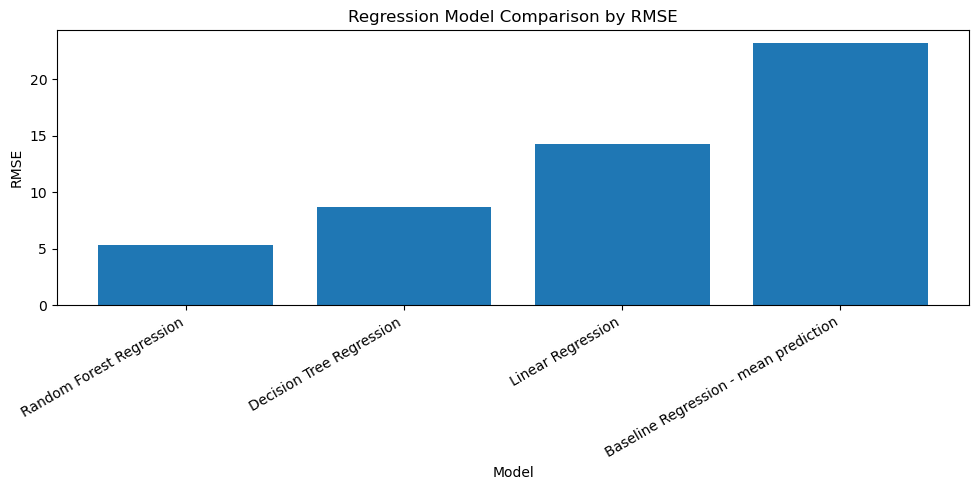

In [483]:
plt.figure(figsize=(10, 5))

plt.bar(
    regression_results["model"],
    regression_results["RMSE"]
)

plt.title("Regression Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Regression Model Comparison Interpretation

The regression results show that machine learning models can predict Google Trends search interest much better than the baseline model. The baseline regression model has the highest RMSE and a negative R² score, which means predicting only the average trend score is not useful for this task.

The Linear Regression model improves over the baseline, but its performance is weaker than the tree-based models. This suggests that search interest patterns are not fully explained by simple linear relationships.

The Decision Tree model performs better than Linear Regression, and the Random Forest model performs the best overall. Random Forest Regression has the lowest error values and the highest R² score. This indicates that a flexible tree-based model can capture non-linear changes in search interest across time, keyword, category, and platform type.

Overall, the regression results support the machine learning analysis by showing that search interest levels are not random. They can be predicted from the available features, especially with non-linear models.

## 27. Actual vs Predicted Trend Scores

This section visualizes the prediction quality of the best regression model by comparing actual and predicted trend scores.

**Code purpose:** Generate predictions from the Random Forest regression model.

In [484]:
regression_y_pred = forest_regression_model.predict(X_reg_test)

actual_vs_predicted = pd.DataFrame({
    "actual_trend_score": y_reg_test.values,
    "predicted_trend_score": regression_y_pred
})

actual_vs_predicted.head()

,actual_trend_score,predicted_trend_score
0,16.0,18.975595
1,12.0,11.606314
2,11.0,21.096073
3,49.0,42.689340
4,30.0,30.423723


**Code purpose:** Plot actual vs predicted trend scores for the Random Forest regression model.

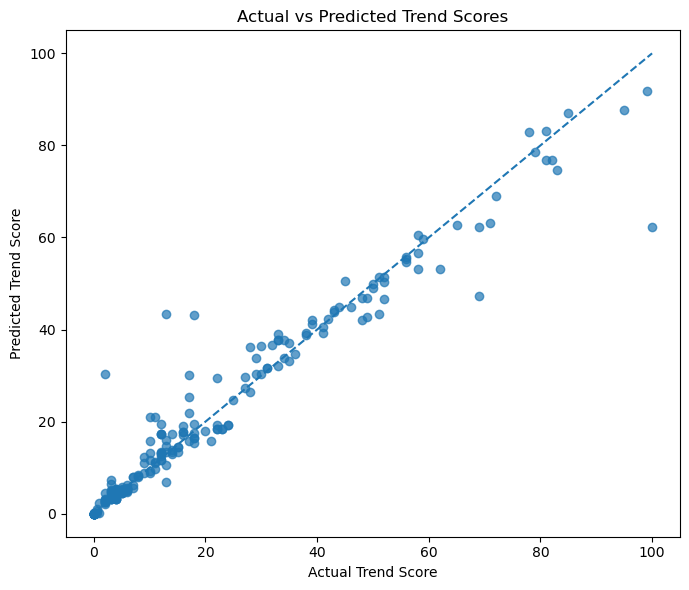

In [485]:
plt.figure(figsize=(7, 6))

plt.scatter(
    actual_vs_predicted["actual_trend_score"],
    actual_vs_predicted["predicted_trend_score"],
    alpha=0.7
)

plt.plot(
    [actual_vs_predicted["actual_trend_score"].min(), actual_vs_predicted["actual_trend_score"].max()],
    [actual_vs_predicted["actual_trend_score"].min(), actual_vs_predicted["actual_trend_score"].max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Trend Scores")
plt.xlabel("Actual Trend Score")
plt.ylabel("Predicted Trend Score")
plt.tight_layout()
plt.show()

### Actual vs Predicted Interpretation

The actual vs predicted plot shows that the Random Forest regression model predicts most Google Trends scores closely. Many points are located near the diagonal line, which means the predicted trend scores are close to the actual trend scores.

The model performs especially well for low and medium trend scores. Some higher trend-score observations are farther from the diagonal line, which suggests that sudden search interest spikes are harder to predict.

Overall, this plot supports the regression results. The Random Forest model captures the general search interest pattern well, but extreme peaks in Google Trends data can still be difficult to estimate perfectly.

## 28. Machine Learning Results Summary

This section summarizes the main machine learning findings in one table before the final interpretation.

**Code purpose:** Create a compact summary table for the main machine learning findings.

In [486]:
ml_results_summary = pd.DataFrame({
    "Analysis part": [
        "Classification baseline",
        "Best pattern-only classifier",
        "Full-feature classifiers",
        "Confusion matrix / error analysis",
        "Cross-validation",
        "Time-based split",
        "Best regression model"
    ],
    "Main result": [
        "Baseline could not identify AI observations",
        "Random Forest pattern-only performed best",
        "Full-feature models reached perfect performance",
        "Most observations were classified correctly; most errors were in study-support",
        "Model performed better than baseline on average",
        "Performance decreased compared with random split",
        "Random Forest Regression performed best"
    ],
    "Interpretation": [
        "Predicting only the majority class is not useful for this project",
        "AI and non-AI observations are distinguishable even without keyword names",
        "Keyword names strongly reveal platform type, so these results are interpreted carefully",
        "Study-support trends are more complex and can overlap",
        "Trend patterns are learnable, but performance varies across folds",
        "AI-related search behavior changes over time",
        "Trend scores can be predicted better with a non-linear model"
    ]
})

ml_results_summary

,Analysis part,Main result,Interpretation
0,Classification baseline,Baseline could not identify AI observations,Predicting only the majority class is not usef...
1,Best pattern-only classifier,Random Forest pattern-only performed best,AI and non-AI observations are distinguishable...
2,Full-feature classifiers,Full-feature models reached perfect performance,"Keyword names strongly reveal platform type, s..."
3,Confusion matrix / error analysis,Most observations were classified correctly; m...,Study-support trends are more complex and can ...
4,Cross-validation,Model performed better than baseline on average,"Trend patterns are learnable, but performance ..."
5,Time-based split,Performance decreased compared with random split,AI-related search behavior changes over time
6,Best regression model,Random Forest Regression performed best,Trend scores can be predicted better with a no...


## 29. Overall Machine Learning Interpretation and Conclusion

The machine learning results support the main project argument that AI-related and non-AI platform observations show different trend behavior.

The strongest classification evidence comes from the pattern-only Random Forest model because it performed well without using keyword names. This suggests that trend score, time, and category information are enough to distinguish many AI-related observations from non-AI observations.

The validation results add an important caution. Cross-validation and time-based testing show that model performance changes across periods, meaning AI-related search behavior is dynamic rather than fixed.

The regression results also support the analysis because Random Forest Regression predicted trend scores better than the baseline and simpler models.

Overall, the results suggest that AI-related search behavior is distinct and measurable, but they should not be interpreted as proof that traditional platforms have been fully replaced.